In [1]:
import os
import yaml
import re 

import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches


import healpy as hp
from reproject import reproject_from_healpix
import json

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

Welcome to JupyROOT 6.30/04


13:38:41 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=150122;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=646852;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=51789;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=24091;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

13:38:42 INFO      Starting 3ML!                                                                     ]8;id=486290;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=206127;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=553092;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=42380;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=607785;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=453713;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=116502;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=710720;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=776340;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=262913;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=205841;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=832723;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=667899;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=421743;file:///data/disk01/home/igherzog/hawc_software/miniconda3/envs/new_hal/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
####List files in directory

model_dir='/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/ModelsMaps/finishedModels2/'
files_in_directory = os.listdir(model_dir)
# Filter to show only files (exclude directories)
with open('injected-model-list.txt', 'w') as file:
    for filename in files_in_directory:
        file.write(filename + '\n')
files = [f for f in files_in_directory if os.path.isfile(os.path.join(model_dir, f))]
print(f"Number of Model Files: {len(files)}")

fit_dir = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'
directory_count = sum(os.path.isdir(os.path.join(fit_dir, d)) for d in os.listdir(fit_dir))
print(f"Number of Model Directory: {directory_count}")

# Check if catalog_results exists
num = 1
run_numbers = np.linspace(1, 249, 249)
for run_number in run_numbers:
    try:
        catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
        fitted_sources = parse_yaml_file(catalog_results)
    except FileNotFoundError:
        # print(f"Warning: catalog_results for run {int(run_number)} does not exist.")
        num = num+1
        skip_val = 1
print(f'Total Number of Fits with no Final Refit: {num} and with Final Refit: {directory_count-num}')

Number of Model Files: 249
Number of Model Directory: 249
Total Number of Fits with no Final Refit: 102 and with Final Refit: 147


In [3]:
outdir = os.getcwd()+ '/simplots/'
if not os.path.exists(outdir):
    os.makedirs(outdir)

run_number = 10

pdf = PdfPages(os.path.join(outdir, f'run-{run_number}-plots.pdf')) 
# Load the Simulation FITS file

run_number_str = str(run_number)
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

injected_model_yaml = "injected-model-list.txt"
with open(injected_model_yaml, 'r') as filelist:
    lines=filelist.readlines()

ra_list=[]
dec_list = []
run_number_list = []
for i, run in enumerate(lines):
    run = run.strip()
    ra,dec = extract_ra_dec(run)
    run_number2 = extract_run(run)
    ra_list.append(ra)
    dec_list.append(dec)
    run_number_list.append(int(run_number2))

run_index = run_number_list.index(run_number)

ra_center = ra_list[run_index]
dec_center = dec_list[run_index]

# Extract names, ra, dec, and sigma from injected_sources
model_file = model_dir + 'model_'+str(int(run_number))+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'
injected_sources = parse_yaml_file(model_file)
inj_names = [source['source_name'] for source in injected_sources]
ra_vals = [source['lon0'] for source in injected_sources]
dec_vals = [source['lat0'] for source in injected_sources]
ext_vals = [source['sigma'] for source in injected_sources]
# spec_vals = [source['spectrum'] for source in injected_sources]
# index_vals = [source['index'] for source in injected_sources]

try:
    catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
    fitted_sources = parse_yaml_file(catalog_results)
    rec_names = [source['source_name'] for source in fitted_sources]
    rec_ra_vals = [source['lon0'] for source in fitted_sources]
    rec_dec_vals = [source['lat0'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]
except:
    catalog_results = f"{fit_dir}model_{int(run_number)}/models/curModel.model"
    fitted_sources = parse_model_file(catalog_results)
    rec_names = [source['name'] for source in fitted_sources]
    rec_ra_vals = [source['ra'] for source in fitted_sources]
    rec_dec_vals = [source['dec'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]

print(ext_vals)
print(ra_vals)

# Step 1: Add text to the PDF
fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
ax.axis('off')  # Turn off axes
text = f"DRIPS Compilation of Result for Simulation Run {run_number} with (RA, Dec) = ({ra_center}, {dec_center})"
ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
pdf.savefig(fig)  
# plt.show()
plt.close(fig)

[1.0969786774556953]
[197.33836914465329]


In [4]:
# Load the Simulation FITS file
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

print(f"ROI center {ra_center}, {dec_center}")
model_file = model_dir + '/model_'+str(run_number)+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'

coord_sys = 'C'
x = ra_center
y = dec_center
xlength=11
ylength=12

#Define ROI
origin = [ra_center, dec_center, xlength, ylength] 
ra_center = "{:.2f}".format(ra_center)
dec_center = "{:.2f}".format(dec_center)

# array, footprint, wcs = loadmap(filename, coord_sys, origin, 'origin')
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)
npix = pixel_size
xnum = array.shape[1]
ynum = array.shape[0]
print(f'Shape of Map in pixel number: {xnum} X {ynum}')
# pixel_size = wcs.wcs.cdelt[1]
print(f'Degrees per pixel: {pixel_size} ')

ROI center 200.02, 35.49
ROI center in Celestial Coordintes = 200.02, 35.49
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 200.02 35.49 
CRPIX : 1980.0 2160.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00277777777777777 0.002777777777777778 
NAXIS : 3960  4320
Fits File loaded
Degrees per pixel: 0.002777777777777778 
Shape of Map in pixel number: 3960 X 4320
Degrees per pixel: 0.002777777777777778 


Maximum Significance in the map is 7.965101018984948 $\sigma$
Minimum Significance in the map is -5.7620774330076205 $\sigma$


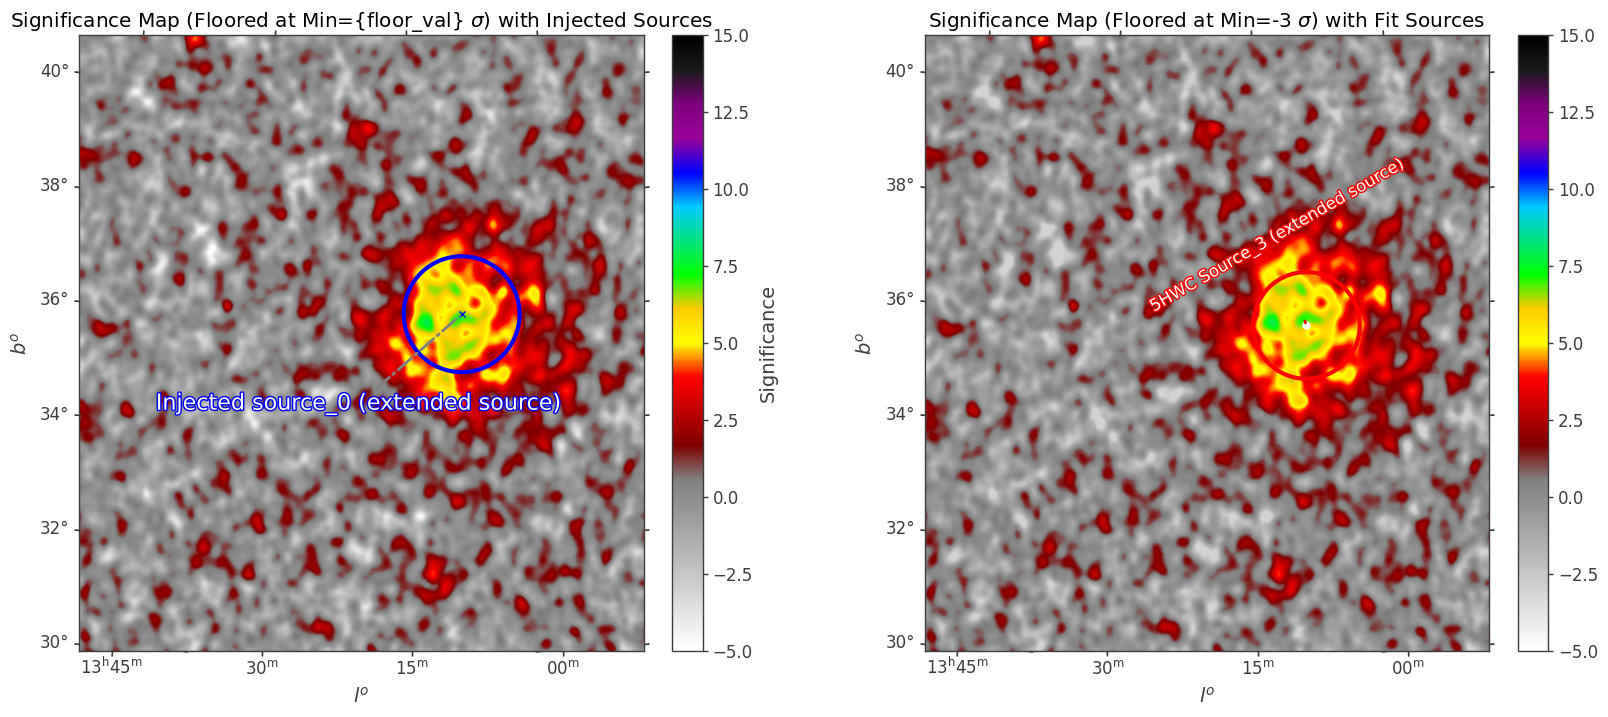

<Figure size 640x480 with 0 Axes>

In [5]:
fig = plt.figure(figsize=(20,8))
ax = plt.subplot(1,2,1, projection=wcs)#,frame_class=EllipticalFrame)
im=ax.imshow(array,  cmap=milagro, vmin=-5, vmax=15)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
ax.set_ylabel(r"$b^o$")
ax.set_xlabel(r"$l^o$")
ax.set_title('Significance Map (Floored at Min={floor_val} $\sigma$) with Injected Sources')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
color_custom = cm.Greys(np.linspace(0.5, 1, len(rec_names)))
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
# custom_sources_plot2(rec_names, rec_ra_vals , rec_dec_vals, rec_ext_vals, ax, wcs, color=color_custom )


max_s = np.max(array)
print(r"Maximum Significance in the map is {} $\sigma$".format(max_s))
print(r"Minimum Significance in the map is {} $\sigma$".format(np.min(array)))
floor_val = -3
narray = invrelu(array, floor_min=floor_val)

ax3 = plt.subplot(1,2, 2, projection=wcs)#,frame_class=EllipticalFrame)
im3=ax3.imshow(narray,  cmap=milagro, vmin=-5, vmax=15)
fig.colorbar(im3, orientation='vertical',fraction=0.046, pad=0.04)
ax3.set_ylabel(r"$b^o$")
ax3.set_xlabel(r"$l^o$")
ax3.set_title(f'Significance Map (Floored at Min={floor_val} $\sigma$) with Fit Sources')
color_custom = cm.Greys(np.linspace(0.5, 1, len(rec_names)))
custom_sources_plot2(rec_names, rec_ra_vals , rec_dec_vals, rec_ext_vals, ax3, wcs, npix=npix )
ax3.set_xlim(0, xnum)
ax3.set_ylim(0, ynum)
# pdf.savefig(fig)
plt.show()
plt.clf()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


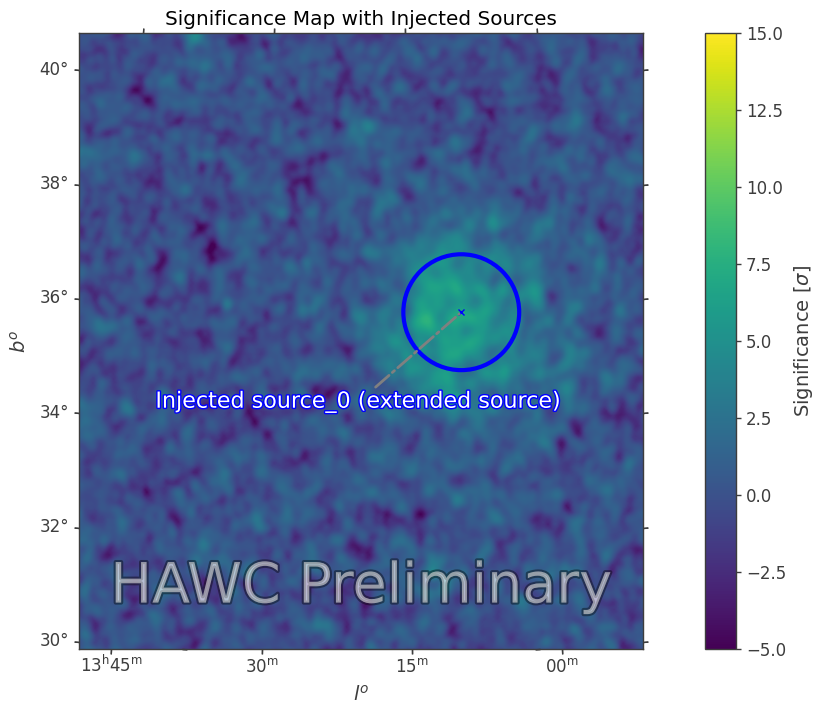

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.patheffects as path_effects
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

fig = plt.figure(figsize=(20,8))
ax = plt.subplot(1,1,1, projection=wcs)#,frame_class=EllipticalFrame)
# im=ax.imshow(array,  cmap=milagro, vmin=-5, vmax=15)
im=ax.imshow(array,  cmap='viridis', vmin=-5, vmax=15)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label=f'Significance [$\sigma$]')
ax.set_ylabel(r"$b^o$")
ax.set_xlabel(r"$l^o$")
ax.set_title(f'Significance Map with Injected Sources')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
color_custom = cm.Greys(np.linspace(0.5, 1, len(rec_names)))
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
text_obj = ax.text(
    0.5, 0.1, 'HAWC Preliminary',
    transform=ax.transAxes,
    fontsize=40,
    color='white',
    alpha=0.4,
    ha='center',
    va='center',
    rotation=0,
    zorder=10
)

# Add path effects for border
text_obj.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])
plt.savefig("Map.png")
plt.show()
plt.clf()

In [7]:
# if v_max < 4.5:
#     print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
#     fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
#     ax.axis('off')  # Turn off axes
#     text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
#     ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
#     # plt.show()
#     pdf.savefig(fig)  # Save the text page
#     plt.close(fig)
#     pdf.close()
#     exit

In [8]:
print(np.min(array))
print(np.max(array))
if np.min(array) < -5:
    print("Image Floored to -5 sigma")
    array = invrelu(array, floor_min=-5)

-5.7620774330076205
7.965101018984948
Image Floored to -5 sigma


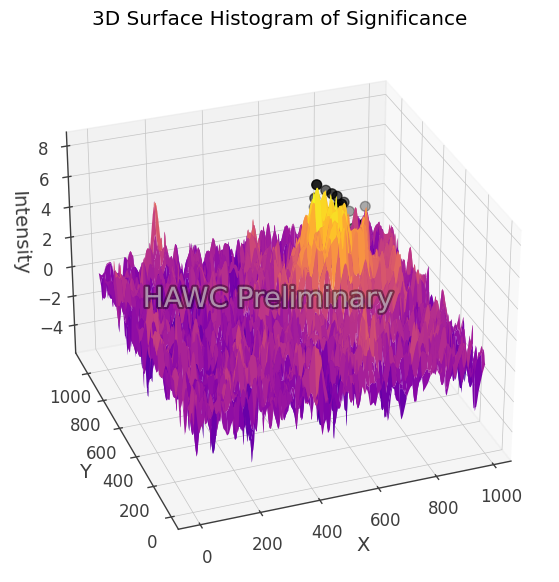

In [9]:
# Make the 3D Intensity Distribution
smoothed = array
smoothed = smoothed[::4, ::4]
x = np.arange(smoothed.shape[1])
y = np.arange(smoothed.shape[0])
X, Y = np.meshgrid(x, y)

coordinates = peak_local_max(smoothed, min_distance=5, threshold_rel=0.1)
peak_x = coordinates[:, 1]
peak_y = coordinates[:, 0]
peak_z = smoothed[peak_y, peak_x]

mask = peak_z > 5
peak_x = peak_x[mask]
peak_y = peak_y[mask]
peak_z = peak_z[mask]

fig = plt.figure(figsize=(9, 7))#, dpi=400)
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(X, Y, smoothed, cmap='plasma', edgecolor='none')
peaks_plot = ax.scatter(peak_x, peak_y, peak_z, c='black', s=50, label='Peaks')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Intensity')
ax.set_title('3D Surface Histogram of Significance')
ax.view_init(elev=30, azim=250)
text_obj = fig.text(
    0.5, 0.5, 'HAWC Preliminary',
    fontsize=20,
    color='white',
    alpha=0.4,
    ha='center',
    va='center',
    rotation=0,
    zorder=10
)
text_obj.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])
plt.savefig("IntensityPeak.png")
# def update(frame):
#     ax.view_init(elev=30, azim=frame)
#     return fig,

# ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
# ani.save(f'gaussian_surface_rotation-{1825}.gif', writer='pillow')

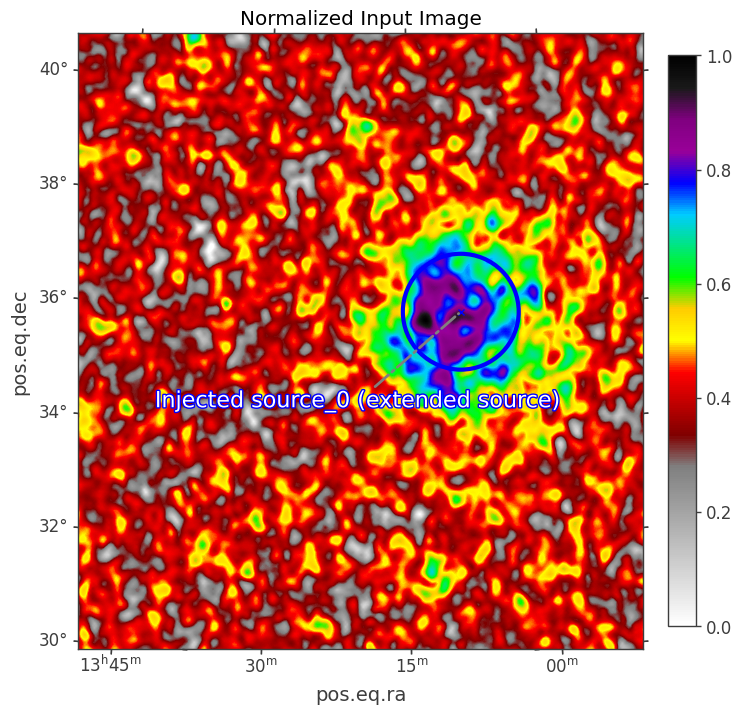

In [10]:
#Normalize Image

image = array
image = (image-np.min(image))/(np.max(image)-np.min(image))
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(1,1,1, projection=wcs)

im=ax.imshow(image,  cmap=milagro)
fig.colorbar(im, orientation='vertical' ,fraction=0.046, pad=0.04)
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
ax.set_title("Normalized Input Image")
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
plt.show()
# pdf.savefig(fig, bbox_inches='tight') 
plt.close(fig)

Length of bins=17107


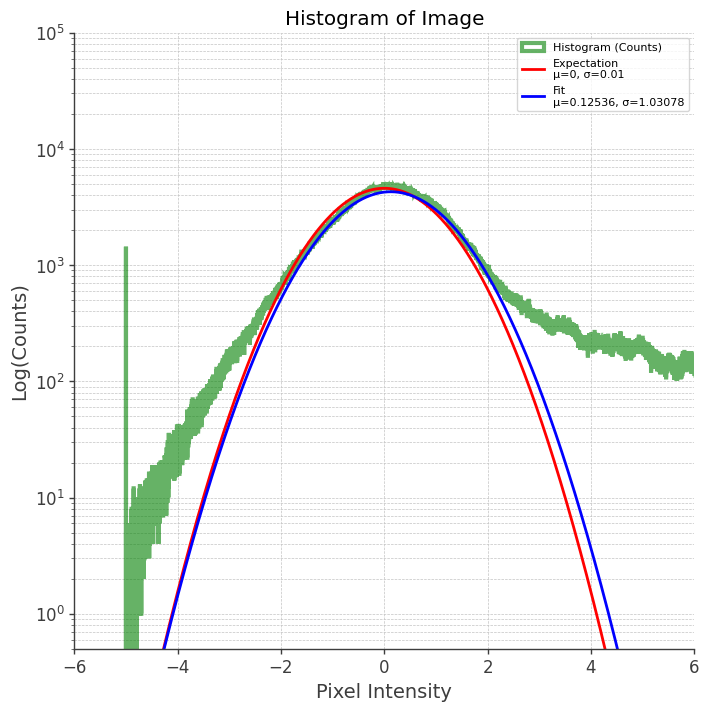

In [11]:
from scipy.stats import norm
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

#Expectation
x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e5)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
# pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

0.24019821673216038
0.8558013666532791


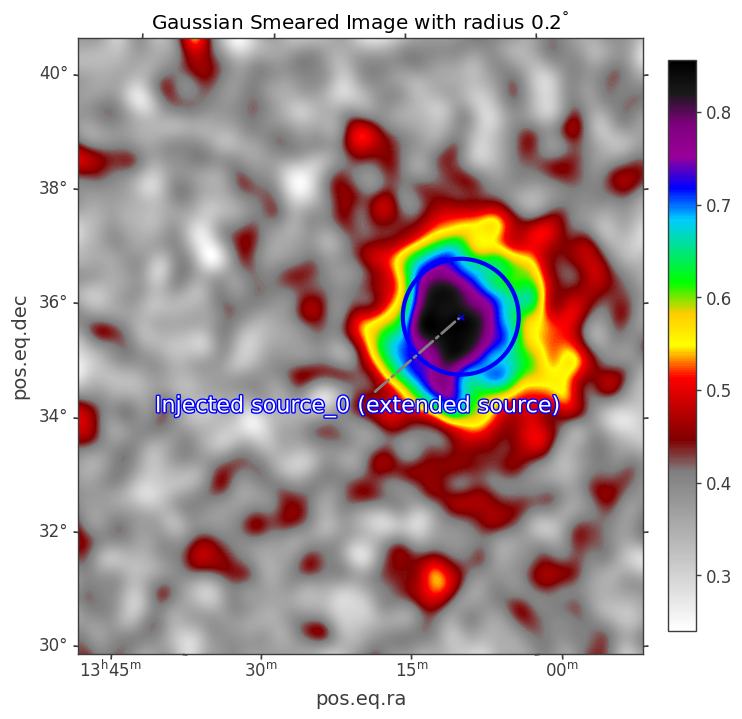

In [12]:
#Smearing Image with a gaussian
image = image
smear_radius = 0.2
gimage = gaussian(image, sigma=smear_radius/pixel_size)
print(np.min(gimage))
print(np.max(gimage))
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(1,1,1, projection=wcs)

im=ax.imshow(gimage,  cmap=milagro)
fig.colorbar(im, orientation='vertical' ,fraction=0.046, pad=0.04)
ax.set_title(f"Gaussian Smeared Image with radius {smear_radius}$^\degree$")
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
plt.show()
# pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
72.0


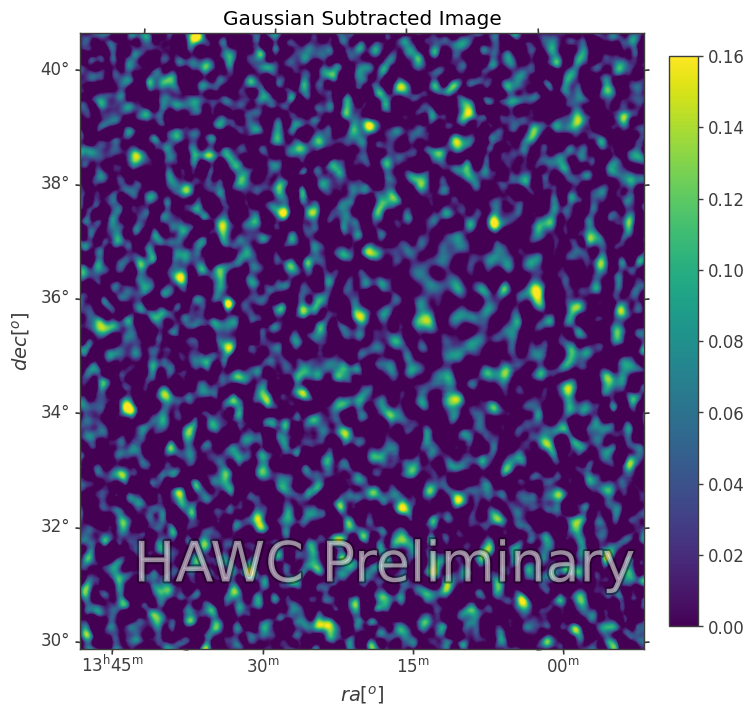

In [13]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
psf=0.2 #PSF of the dec band
print(psf/pixel_size)
new_image = difference_of_gaussians(image, 1, psf/pixel_size)
fig = plt.figure(figsize=(8,8))
ax2 = plt.subplot(1,1,1, projection=wcs)
new_image = gaussian(new_image, sigma=3)
im2=ax2.imshow(new_image,  cmap=milagro, vmin=0)#, vmax=0.7)#, vmax =0.1)#, vmax=0.1)
im2=ax2.imshow(new_image,  cmap='viridis', vmin=0, vmax=0.16)#, vmax=0.7)#, vmax =0.1)#, vmax=0.1)
fig.colorbar(im2, orientation='vertical',fraction=0.046, pad=0.04)
plot_ax_label(ax2, coord_sys='C')
ax2.set_title(f'Gaussian Subtracted Image')
text_obj = ax2.text(
    0.5, 0.1, 'HAWC Preliminary',
    transform=ax.transAxes,
    fontsize=40,
    color='white',
    alpha=0.4,
    ha='center',
    va='center',
    rotation=0,
    zorder=10
)

# Add path effects for border
text_obj.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])
# injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax2, wcs )
# injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax2, wcs )
plt.savefig('Resmap.png')
plt.xlim(0, xnum)
plt.ylim(0, ynum)
plt.show()
# pdf.savefig(fig, bbox_inches='tight')

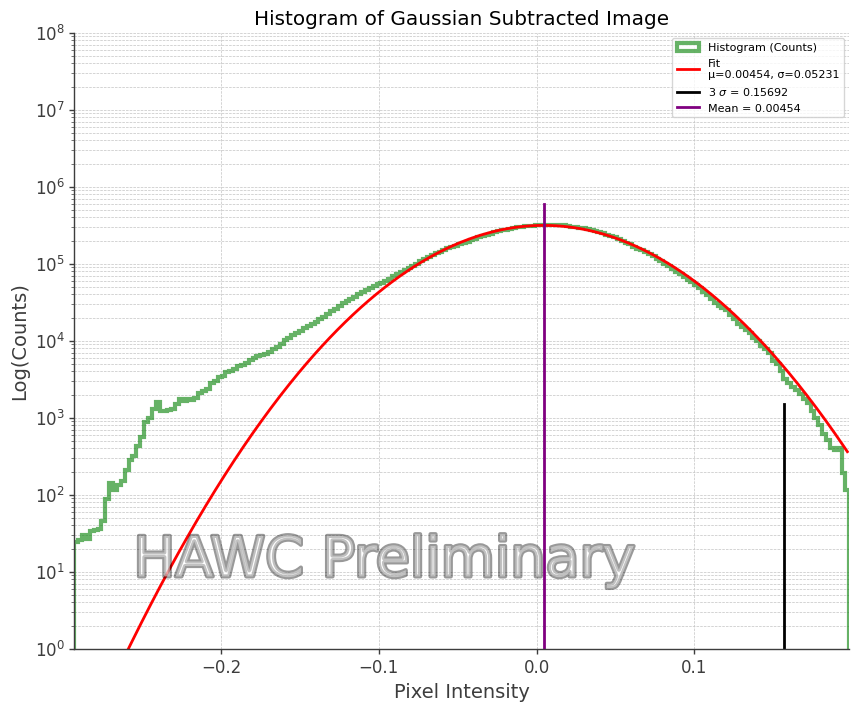

In [14]:
from scipy.stats import norm
pixels = new_image.flatten()
sigma_resid2 = np.std(new_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

#Expectation
x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)

############################################################## 
################## MY JOB, FIND VALUE FOR 3 ##################
##############################################################
sigma_resid = popt[2]
deviation = 3*sigma_resid
plt.figure(figsize=(10, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=200, range=(np.min(pixels), np.max(pixels)),  color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)',histtype='step', linewidth=3)
# plt.plot(x_exp, y_exp, 'cyan', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
text_obj = plt.text(
    0.5, 0.1, 'HAWC Preliminary',
    transform=ax.transAxes,
    fontsize=40,
    color='white',
    alpha=0.4,
    ha='center',
    va='center',
    rotation=0,
    zorder=10
)

# Add path effects for border
text_obj.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])
# plt.axvline(sigma_resid, label=f'1 $\sigma$ = {popt[2]:.5f} ', color='blue', x=1)
# plt.axvline(deviation, label=f'3 $\sigma$  = {3*popt[2]:.5f}', color='black')
plt.plot([deviation, deviation], [1, 1.5e3], color='black', linewidth=2, label=f'3 $\sigma$ = {3*popt[2]:.5f}')
# plt.axvline(popt[1], label=f'Mean = {popt[1]:.5f}')
plt.plot([popt[1], popt[1]], [1, 6e5], color='purple', linewidth=2, label=f'Mean = {popt[1]:.5f}')
plt.yscale('log')
plt.ylim(1, 1e8)
plt.xlim(np.min(bin_edges), np.max(bin_edges))
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Gaussian Subtracted Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.savefig("ResGaussian.png")
plt.show()
# pdf.savefig(fig, bbox_inches='tight')

plt.close(fig)

In [15]:
ps_blobs = blob_dog(new_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=0.01, exclude_border=20)#, overlap=0.9)
print("Number of point source blobs=",len(ps_blobs))
ext_blobs = blob_dog(new_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=0.01, exclude_border=20)#, overlap=0.9)
print("Number of ext source blobs=",len(ext_blobs))

Number of point source blobs= 489
Number of ext source blobs= 173


In [16]:
# intensity_min = deviation
# intensity_min2 = deviation
intensity_min = deviation
intensity_min2 = deviation


print(intensity_min2)
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, new_image, intensity_min, wcs, npix=npix)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, new_image, intensity_min2, wcs, npix=npix)
print("No of ext = ", len(ext_filtered_blobs))

0.15691697281146919
Blob Intensity 0.17563143308657017, Coords (206.14893994080919 deg, 34.154678766802 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.16587791013266237, Coords (195.35136908810748 deg, 36.241284471014865 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.16424635860731676, Coords (196.40674785881498 deg, 37.508414469770926 deg), Radius 36.0, Pixel Radius 0.1
No of ps =  3
No of ext =  0


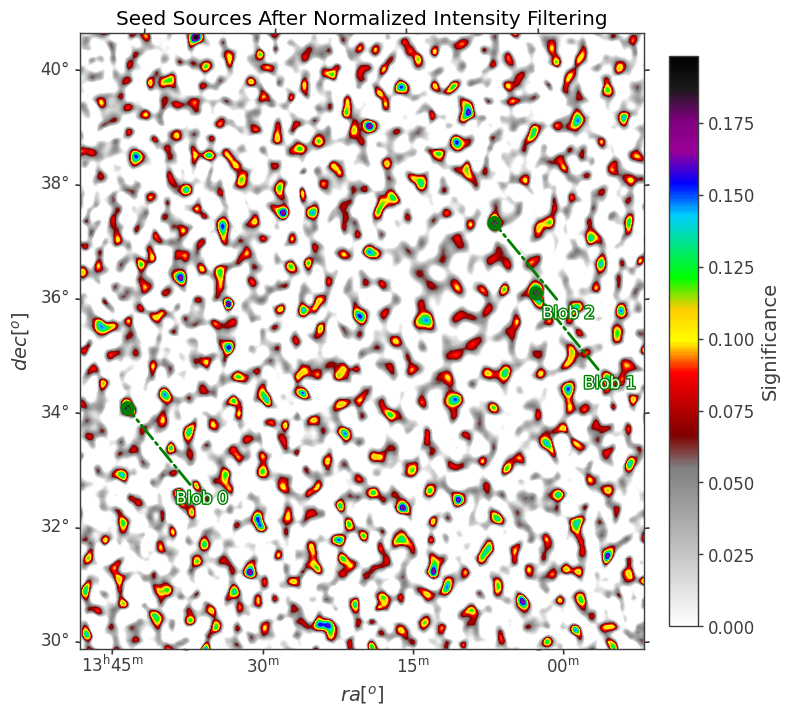

In [17]:
fig=plt.figure(figsize=(8, 8))
ax = plt.subplot(1,1,1, projection=wcs)
im=ax.imshow(new_image, cmap=milagro, vmin=0)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.set_title("Seed Sources After Normalized Intensity Filtering")
plot_ax_label(ax, coord_sys)
plot_ps_blob(ax, ps_filtered_blobs, wcs)
plot_ext_blob(ax, ext_filtered_blobs, wcs)
# injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
plt.show()
# pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

Blob Intensity 5.291916404502742, Coords (195.35136908810748 deg, 36.241284471014865 deg), Radius 36.0, Pixel Radius 0.1
No of ps =  1
No of ext =  0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


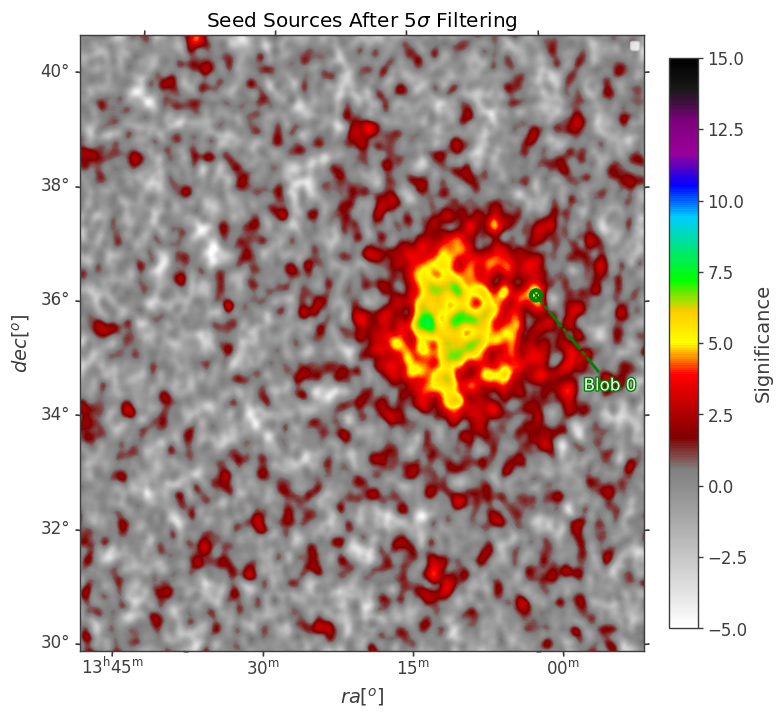

In [18]:
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, npix=npix)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 4, wcs, npix=npix)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))

fig=plt.figure(figsize=(8, 8))
ax = plt.subplot(1,1,1, projection=wcs)
im=ax.imshow(array, cmap=milagro, vmin=-5, vmax=15)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.set_title(f"Seed Sources After 5$\sigma$ Filtering")
ax.legend(loc='upper right')
plot_ax_label(ax, coord_sys)
plot_ps_blob(ax, ps_filtered_blobs2, wcs)
# plot_ext_blob(ax, ext_filtered_blobs3, wcs)
# injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
plt.show()
# pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

In [19]:
ext_blobs2 = blob_dog(gimage,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.05, exclude_border=80)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))

Number of ext source blobs= 1


Blob Intensity 5.937095258056105, Coords (197.56605189362315 deg, 35.80287902097407 deg), Radius 288.0, Pixel Radius 0.8


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


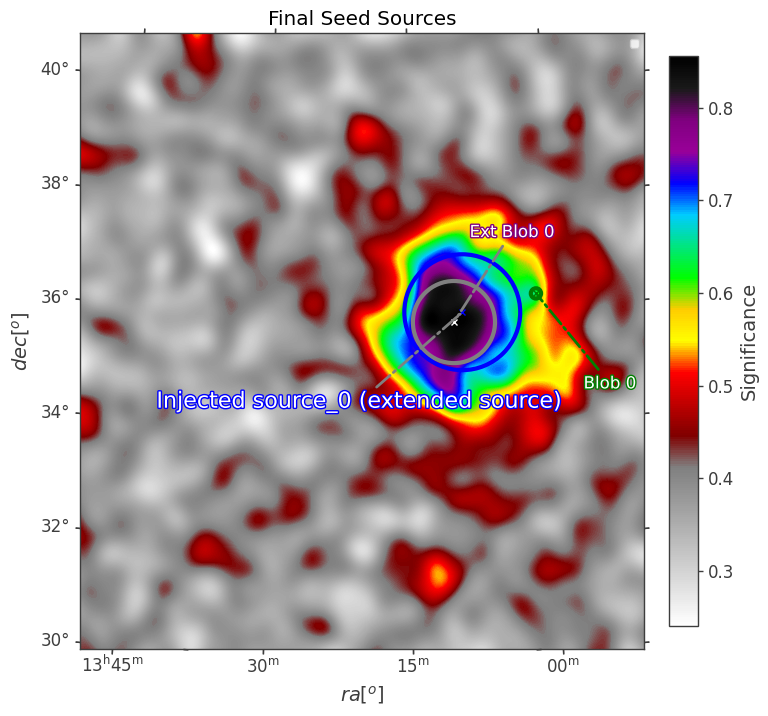

In [20]:
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 3, wcs, npix=npix)
fig=plt.figure(figsize=(8, 8))
ax = plt.subplot(1,1,1, projection=wcs)
image=ax.imshow(gimage, cmap=milagro)#, vmin=-5, vmax=15)
fig.colorbar(image, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.set_title("Final Seed Sources")
ax.legend(loc='upper right')
plot_ax_label(ax, coord_sys)
plot_ps_blob(ax, ps_filtered_blobs2, wcs)
plot_ext_blob(ax, ext_filtered_blobs3, wcs)
plot_ext_blob(ax, ext_filtered_blobs2, wcs)
# plot_ext_blob(ax, ext_blobs2, wcs)
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
# pdf.savefig(fig, bbox_inches='tight')
plt.show()
plt.close(fig)

[<SkyCoord (ICRS): (ra, dec) in deg
    (195.35136909, 36.24128447)>, <SkyCoord (ICRS): (ra, dec) in deg
    (197.56605189, 35.80287902)>]
   Names          ra        dec  Circle Radius  Sigma Radius
0  Drip0  195.351369  36.241284            0.1      0.065998
1  Drip1  197.566052  35.802879            0.8      0.527985


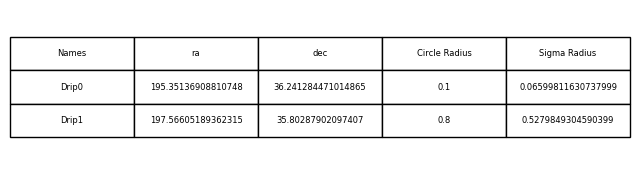

In [21]:
total_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3
total_blobs = ps_filtered_blobs2 + ext_filtered_blobs2 + ext_filtered_blobs3
print(total_coords)
total_coords_ra = [ i.ra.value for i in ps_filtered_coords2] +[i.ra.value for i in ext_filtered_coords2] + [i.ra.value for i in ext_filtered_coords3]
total_coords_dec = [ i.dec.value for i in ps_filtered_coords2] +[i.dec.value for i in ext_filtered_coords2] + [i.dec.value for i in ext_filtered_coords3]
total_radius = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3
names = ['Drip'+str(i) for i in range(len(total_coords))]
df = pd.DataFrame(names, columns=['Names'])
df['ra'] = total_coords_ra
df['dec'] = total_coords_dec
df['Circle Radius'] = total_radius
def radius_to_sigma(R, fraction=0.6827):
    return R / np.sqrt(2 * np.log(1 / (1 - fraction)))

sigma_list = []
for R in total_radius:
    sigma = radius_to_sigma(R)
    sigma_list.append(sigma)

df['Sigma Radius'] = sigma_list

keep = np.ones(len(df), dtype=bool)

for i in range(len(df)):
    if not keep[i]:
        continue 
    for j in range(i + 1, len(df)):
        distance = np.sqrt((df.loc[i, 'ra'] - df.loc[j, 'ra'])**2 +
                           (df.loc[i, 'dec'] - df.loc[j, 'dec'])**2)
        radius1 = df.loc[i, 'Sigma Radius']
        radius2 = df.loc[j, 'Sigma Radius']
        if distance < 0.3:
            if radius1 > 0.1:
                keep[j] = False
            elif radius2 > 0.1:
                keep[i] = False
            elif radius1 < radius2:
                keep[j] = False

filtered_df = df[keep].reset_index(drop=True)
print(filtered_df)

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
# pdf.savefig(fig, bbox_inches='tight') 
plt.close(fig)

[<SkyCoord (ICRS): (ra, dec) in deg
    (195.35136909, 36.24128447)>, <SkyCoord (ICRS): (ra, dec) in deg
    (197.56605189, 35.80287902)>]
   Names          ra        dec  Circle Radius  Sigma Radius
0  Drip0  195.351369  36.241284            0.1      0.065998
1  Drip1  197.566052  35.802879            0.8      0.527985


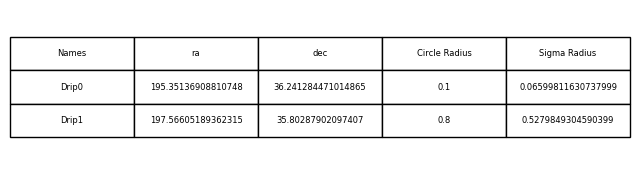

In [22]:
total_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3
total_blobs = ps_filtered_blobs2 + ext_filtered_blobs2 + ext_filtered_blobs3
print(total_coords)
total_coords_ra = [ i.ra.value for i in ps_filtered_coords2] +[i.ra.value for i in ext_filtered_coords2] + [i.ra.value for i in ext_filtered_coords3]
total_coords_dec = [ i.dec.value for i in ps_filtered_coords2] +[i.dec.value for i in ext_filtered_coords2] + [i.dec.value for i in ext_filtered_coords3]
total_radius = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3
names = ['Drip'+str(i) for i in range(len(total_coords))]
df = pd.DataFrame(names, columns=['Names'])
df['ra'] = total_coords_ra
df['dec'] = total_coords_dec
df['Circle Radius'] = total_radius
def radius_to_sigma(R, fraction=0.6827):
    return R / np.sqrt(2 * np.log(1 / (1 - fraction)))

sigma_list = []
for R in total_radius:
    sigma = radius_to_sigma(R)
    sigma_list.append(sigma)

df['Sigma Radius'] = sigma_list

keep = np.ones(len(df), dtype=bool)

for i in range(len(df)):
    if not keep[i]:
        continue 
    for j in range(i + 1, len(df)):
        distance = np.sqrt((df.loc[i, 'ra'] - df.loc[j, 'ra'])**2 +
                           (df.loc[i, 'dec'] - df.loc[j, 'dec'])**2)
        radius1 = df.loc[i, 'Sigma Radius']
        radius2 = df.loc[j, 'Sigma Radius']
        if distance < 0.3:
            if radius1 > 0.1:
                keep[j] = False
            elif radius2 > 0.1:
                keep[i] = False
            elif radius1 < radius2:
                keep[j] = False

filtered_df = df[keep].reset_index(drop=True)
# print(filtered_df)
print(filtered_df.head())

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.savefig('SeedTable.png')
plt.show()
plt.close(fig)

In [23]:
'''

location: +/- 1 degree, step size 0.1
radiux: 0.1 - 3.0, step by 0.1
index: 1.4 - 4.0, step by 0.1
pivot: 7 TeV

'''

ra_vals = np.array(ra_vals)
dec_vals = np.array(dec_vals)
ext_vals = np.array(ext_vals)

print(ra_vals, dec_vals, ext_vals)
print()
print(filtered_df)

def distance(x1, x2, y1, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# Threshold for detection (e.g., match if within this radius in degrees)
psf_radius = 0.3  # you can tune this

# Track matched injections and detections
matched_injected = np.zeros(len(ra_vals), dtype=bool)
matched_found = np.zeros(len(filtered_df), dtype=bool)

# Match detections to injections
for i, (name, ra_f, dec_f, circle, sigma) in filtered_df.iterrows():
    dist = distance(ra_vals, ra_f, dec_vals, dec_f)
    close_matches = np.where(dist < psf_radius)[0]
    
    if len(close_matches) > 0:
        # Assume best match is closest
        closest_idx = close_matches[np.argmin(dist[close_matches])]
        if not matched_injected[closest_idx]:  # avoid double-matching
            matched_injected[closest_idx] = True
            matched_found[i] = True
        else:
            # already matched injection — could be extra FP
            pass
    else:
        # No match — likely FP
        pass

# Calculate confusion matrix components
TP = np.sum(matched_found)       # found sources correctly matched
FP = np.sum(~matched_found)      # found sources with no corresponding injection
FN = np.sum(~matched_injected)   # injections that weren't found
# TN is not well-defined here, so often left out

print(f"TP: {TP}, FP: {FP}, FN: {FN}")
conf_matrix = np.array([[TP, FP],
                        [FN, 0]])  # TN not calculated

print("Confusion Matrix:")
print(conf_matrix)


[197.33836914] [35.9708222] [1.09697868]

   Names          ra        dec  Circle Radius  Sigma Radius
0  Drip0  195.351369  36.241284            0.1      0.065998
1  Drip1  197.566052  35.802879            0.8      0.527985
TP: 1, FP: 1, FN: 0
Confusion Matrix:
[[1 1]
 [0 0]]


In [24]:
# Convert to numpy arrays
ra_vals = np.array(ra_vals)
dec_vals = np.array(dec_vals)
ext_vals = np.array(ext_vals)

# Matching radius threshold
psf_radius = 0.2  # degrees, tweak as needed

# Categorize injected sources
is_injected_point = ext_vals == 0.0
is_injected_ext = ext_vals > 0.0

# Categorize detected sources
is_detected_point = filtered_df['Circle Radius'] <= 0.2
is_detected_ext = filtered_df['Circle Radius'] > 0.2

# Initialize match tracking arrays
matched_injected_point = np.zeros(np.sum(is_injected_point), dtype=bool)
matched_found_point = np.zeros(np.sum(is_detected_point), dtype=bool)

matched_injected_ext = np.zeros(np.sum(is_injected_ext), dtype=bool)
matched_found_ext = np.zeros(np.sum(is_detected_ext), dtype=bool)

# Function to do matching
def perform_matching(ra_inj, dec_inj, ra_found, dec_found, matched_inj, matched_found):
    for i, (ra_f, dec_f) in enumerate(zip(ra_found, dec_found)):
        print(ra_inj)
        print(ra_f)
        print(dec_inj)
        print(dec_f)
        dists = distance(ra_inj, ra_f, dec_inj, dec_f)
        close_matches = np.where(dists < psf_radius)[0]
        
        if len(close_matches) > 0:
            closest_idx = close_matches[np.argmin(dists[close_matches])]
            if not matched_inj[closest_idx]:
                matched_inj[closest_idx] = True
                matched_found[i] = True
    return matched_inj, matched_found

# Extract coordinates for each category
inj_ra_point = ra_vals[is_injected_point]
inj_dec_point = dec_vals[is_injected_point]

print(inj_ra_point, inj_dec_point)

inj_ra_ext = ra_vals[is_injected_ext]
inj_dec_ext = dec_vals[is_injected_ext]

found_point_df = filtered_df[is_detected_point]
found_ext_df = filtered_df[is_detected_ext]

# Match point sources
matched_injected_point, matched_found_point = perform_matching(
    inj_ra_point, inj_dec_point,
    found_point_df['ra'].values, found_point_df['dec'].values,
    matched_injected_point, matched_found_point
)

# Match extended sources
matched_injected_ext, matched_found_ext = perform_matching(
    inj_ra_ext, inj_dec_ext,
    found_ext_df['ra'].values, found_ext_df['dec'].values,
    matched_injected_ext, matched_found_ext
)

# Confusion matrices
TP_point = np.sum(matched_found_point)
FP_point = np.sum(~matched_found_point)
FN_point = np.sum(~matched_injected_point)

TP_ext = np.sum(matched_found_ext)
FP_ext = np.sum(~matched_found_ext)
FN_ext = np.sum(~matched_injected_ext)

conf_matrix_point = np.array([[TP_point, FP_point],
                              [FN_point, 0]])

conf_matrix_ext = np.array([[TP_ext, FP_ext],
                            [FN_ext, 0]])

# Display results
print("Point Source Confusion Matrix:")
print(conf_matrix_point)

print("\nExtended Source Confusion Matrix:")
print(conf_matrix_ext)

# Create a DataFrame with both matrices in a flattened format
results_df = pd.DataFrame({
    'Type': ['Point', 'Extended'],
    'TP': [TP_point, TP_ext],
    'FP': [FP_point, FP_ext],
    'FN': [FN_point, FN_ext]
    # TN is excluded since it’s undefined here
})

# Save to CSV
results_df.to_csv(f"conf_run_{run_number_str}.csv", index=False)

[] []
[]
195.35136908810748
[]
36.241284471014865
[197.33836914]
197.56605189362315
[35.9708222]
35.80287902097407
Point Source Confusion Matrix:
[[0 1]
 [0 0]]

Extended Source Confusion Matrix:
[[0 1]
 [1 0]]


In [30]:
'''
big array attempt

location: +/- 1 degree, step size 0.1
radius: 0.1 - 3.0, step by 0.1
index: 1.4 - 4.0, step by 0.1
pivot: 7 TeV
'''
pivot = int(7)
filtered_df_n = filtered_df

index = np.arange(-4.0, -1.4, 0.1)

# find if source is extended or not
filtered_df_n['ext'] = (filtered_df_n['Sigma Radius'] > psf).astype(int)
filtered_df_n['pivot'] = pivot # TeV
filtered_df_n = filtered_df_n.drop(['Names','Circle Radius', 'Sigma Radius'], axis=1)

params_numpy = filtered_df_n.to_numpy()
# params_numpy[:, 2], params_numpy[:, 3] = params_numpy[:, 3], params_numpy[:, 2].copy()
params_numpy = np.round(params_numpy, 3)

source_ra = params_numpy[:,0]
source_dec = params_numpy[:,1]
source_bool_ext = params_numpy[:,2]
# source_ext = params_numpy[:,3]
source_pivot = params_numpy[:,3]

print(source_ra, source_dec, source_bool_ext, source_pivot)

sources = len(params_numpy)
# print(sources)
# print(params_numpy)

# Repeat each row len(index) times
repeated_params = np.repeat(params_numpy, len(index), axis=0)

# Tile the index values for each row
tiled_index = np.tile(index, len(params_numpy)).reshape(-1, 1)

# Concatenate the repeated params with the tiled index
result = np.hstack((repeated_params, tiled_index))

# print(result)

import numpy as np
np.set_printoptions(suppress=True)


def smart_expand_array(results):
    # Step space for the first two columns
    variations = np.arange(-1, 1.1, 0.1)  # 21 values
    delta_a, delta_b = np.meshgrid(variations, variations)
    delta_pairs = np.stack([delta_a.ravel(), delta_b.ravel()], axis=1)  # (441, 2)

    # For c == 1 → d values range from 0.1 to 3.0 (step 0.1)
    d_variations = np.arange(0.1, 3.1, 0.1)  # 30 values

    all_rows = []

    for row in results:
        a, b, c, d, e = row

        # First get 441 (a, b) combinations
        base_ab = np.tile(row, (441, 1))  # shape (441, 5)
        base_ab[:, 0] += delta_pairs[:, 0]
        base_ab[:, 1] += delta_pairs[:, 1]

        if c == 0:
            # Just one variation: insert 0.1 in column 3
            expanded = np.zeros((441, 6))
            expanded[:, 0:2] = base_ab[:, 0:2]
            expanded[:, 2] = 0  # c
            expanded[:, 3] = 0.1  # fixed value for d
            expanded[:, 4] = d    # original d becomes column 4
            expanded[:, 5] = e
            all_rows.append(expanded)

        elif c == 1:
            # Repeat each of the 441 (a, b) combos 30 times
            base_ab_repeated = np.repeat(base_ab, len(d_variations), axis=0)  # (13230, 5)
            d_values = np.tile(d_variations, 441)  # 30 × 441 = 13230

            expanded = np.zeros((len(d_values), 6))
            expanded[:, 0:2] = base_ab_repeated[:, 0:2]
            expanded[:, 2] = 1  # c
            expanded[:, 3] = d_values  # stepping d
            expanded[:, 4] = d         # original d
            expanded[:, 5] = e
            all_rows.append(expanded)

    return np.vstack(all_rows)

expanded = smart_expand_array(result)
# np.savetxt("big-array-test.csv", expanded, delimiter=',')

np.savetxt(
    "big-array-test.csv",
    expanded,
    delimiter=',',
    fmt=("%.2f", "%.2f", "%d", "%.1f", "%d", "%.1f")
)
print(expanded.shape) 
print(expanded)

np.save("big-array-test.npy", expanded)
loaded = np.load("big-array-test.npy")
print(loaded.shape)
print(loaded[:5])  # preview first 5 rows


[195.351 197.566] [36.241 35.803] [0. 1.] [7. 7.]
(355446, 6)
[[194.351  35.241   0.      0.1     7.     -4.   ]
 [194.451  35.241   0.      0.1     7.     -4.   ]
 [194.551  35.241   0.      0.1     7.     -4.   ]
 ...
 [198.566  36.803   1.      2.8     7.     -1.5  ]
 [198.566  36.803   1.      2.9     7.     -1.5  ]
 [198.566  36.803   1.      3.      7.     -1.5  ]]
(355446, 6)
[[194.351  35.241   0.      0.1     7.     -4.   ]
 [194.451  35.241   0.      0.1     7.     -4.   ]
 [194.551  35.241   0.      0.1     7.     -4.   ]
 [194.651  35.241   0.      0.1     7.     -4.   ]
 [194.751  35.241   0.      0.1     7.     -4.   ]]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


TypeError: custom_sources_plot() missing 1 required positional argument: 'label_rot'

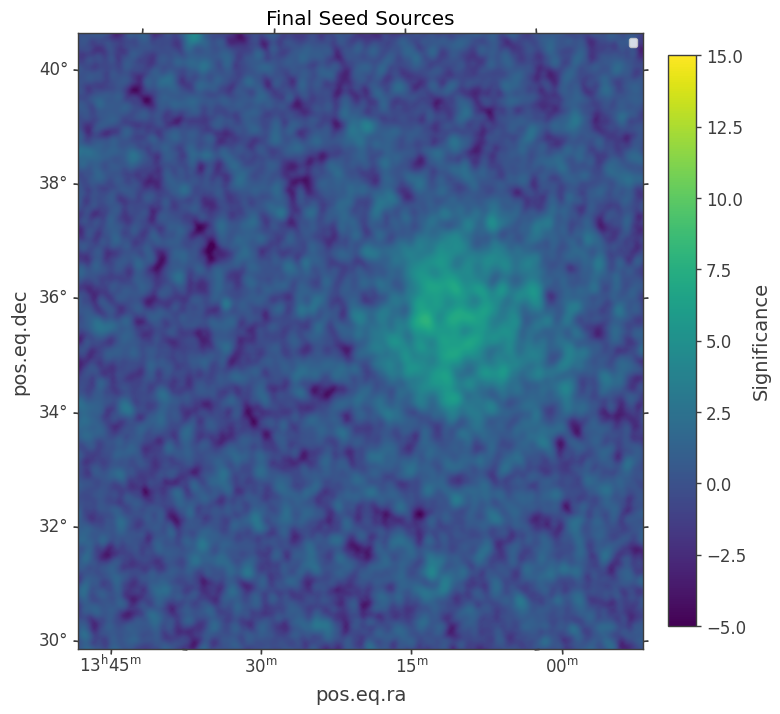

In [29]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
fig=plt.figure(figsize=(8, 8))
ax = plt.subplot(1,1,1, projection=wcs)
im=ax.imshow(array, cmap='viridis', vmin=-5, vmax=15)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.set_title("Final Seed Sources")
ax.legend(loc='upper right')
color = cm.Greys(np.linspace(0.8, 1, len(filtered_df)))
custom_sources_plot(filtered_df['Names'], filtered_df['ra'], filtered_df['dec'], filtered_df['Sigma Radius'], ax=ax, wcs=wcs, npix=npix)
injected_sources_plot(inj_names, ra_vals , dec_vals, ext_vals, ax, wcs )
text_obj = ax.text(
    0.5, 0.1, 'HAWC Preliminary',
    transform=ax.transAxes,
    fontsize=40,
    color='white',
    alpha=0.4,
    ha='center',
    va='center',
    rotation=0,
    zorder=10
)

# Add path effects for border
text_obj.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])
plt.savefig('Seed.png')
plt.show()
plt.close(fig)

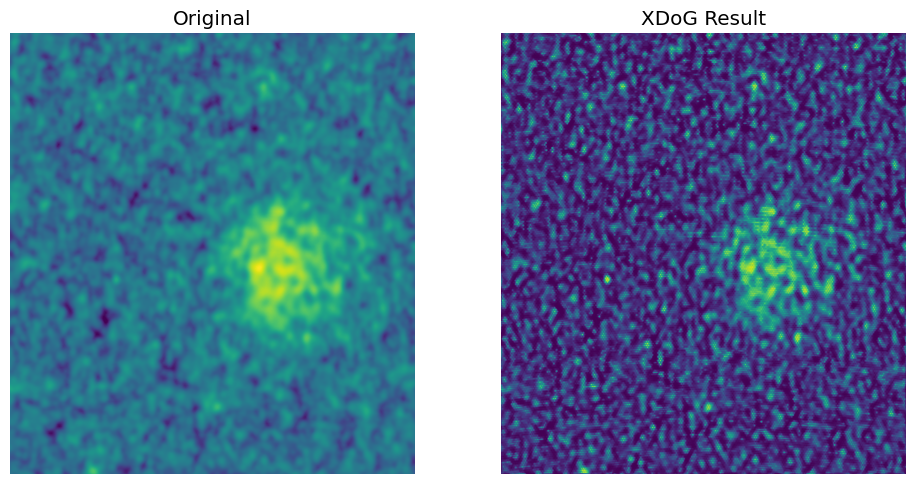

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.filters import gaussian

def xdog_skimage(image, sigma=0.8, k=10, p=0.98, epsilon=0.1, phi=10.0):
    """
    Implements the XDoG algorithm using skimage for filtering.
    
    Parameters:
        image: 2D numpy array (grayscale)
        sigma: Base Gaussian sigma
        k: Sigma multiplier for the second Gaussian
        p: Weight for second Gaussian
        epsilon: Threshold parameter for edge suppression
        phi: Sharpening parameter

    Returns:
        2D numpy array: XDoG-processed image
    """
    image = img_as_float(image)  # Normalize to [0,1]
    
    # Apply Gaussian filters
    g1 = gaussian(image, sigma=1)
    g2 = gaussian(image, sigma=k * sigma)
    
    # Difference of Gaussians (DoG)
    dog = g1 - p * g2
    
    # XDoG sharpening
    xdog = 1.0 + np.tanh(phi * (dog - epsilon))
    
    return xdog

# Example: Load and apply
image = array
xdog_result = xdog_skimage(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image, cmap='viridis')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("XDoG Result")
plt.imshow(xdog_result, cmap='viridis')
plt.axis('off')

plt.tight_layout()
plt.show()
